In [1]:
import os
import statistics
from pathlib import Path
import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from skimage.feature import hog
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split
from sklearn.metrics import make_scorer, accuracy_score, f1_score, confusion_matrix, classification_report
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from google.colab.patches import cv2_imshow

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:

dataset_path = Path("/content/drive/MyDrive/Colab Notebooks/dataset_graph")

In [4]:
# Explore dataset directory to verify folder structure
for p in dataset_path.iterdir():
  print(p)

/content/drive/MyDrive/Colab Notebooks/dataset_graph/misto
/content/drive/MyDrive/Colab Notebooks/dataset_graph/stampatello
/content/drive/MyDrive/Colab Notebooks/dataset_graph/corsivo


In [5]:
# Load a sample image from the cursive class to check dimensions and format
corsivo_path=dataset_path / "corsivo"
prima_img = next(corsivo_path.glob("*.*"))
print(prima_img)
img = cv2.imread(str(prima_img))
print(img.shape)

/content/drive/MyDrive/Colab Notebooks/dataset_graph/corsivo/a01-000x-01.png
(148, 1595, 3)


In [6]:
output_path = dataset_path.parent/"dataset_graph_processed"
output_path.mkdir(exist_ok=True)

classes = ["corsivo", "misto", "stampatello"]
extensions = ("*.png", "*.jpg", "*.jpeg")

for cls in classes:
  input_class_path = dataset_path / cls
  output_class_path = output_path / cls
  output_class_path.mkdir(exist_ok=True)
  # Collect all image paths for this class across all extensions
  img_paths = []
  for ext in extensions:
    for p in input_class_path.glob(ext):
      img_paths.append(p)

  for img_path in img_paths:
    img= cv2.imread(str(img_path))
    if img is None:
      print("Read Error", img_path)
      continue
    # convert to grayscale
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # Binarize with Otsu thresholding (inverted: ink=255, background=0)
    # Inversion is required by OpenCV connected components functions
    ret,otsu = cv2.threshold(
        gray,
        0,
        255,
        cv2.THRESH_BINARY_INV+cv2.THRESH_OTSU
    )
    # Apply morphological opening to remove small noise dots
    # Kernel 2x2,  small to preserve letter strokes
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (2,2))
    clean = cv2.morphologyEx(otsu, cv2.MORPH_OPEN, kernel)

    #Save both versions
    # _otsu.png -> raw binarized image, used for loop detection

    out_file = output_class_path/f"{img_path.stem}_otsu.png"
    cv2.imwrite(str(out_file), otsu)

    #_clean.png -> denoised image, used for connectivity features
    out_file = output_class_path/f"{img_path.stem}_clean.png"
    cv2.imwrite(str(out_file), clean)


print("Output saved in:", output_path)

Output saved in: /content/drive/MyDrive/Colab Notebooks/dataset_graph_processed


In [7]:
def get_components(clean_img, min_area=4):
  """
    Finds all ink blobs in a binary image and returns their stats.
    Blobs smaller than min_area pixels are discarded as noise.

    Parameters ->
        clean_img: binary image (ink=255, background=0).
        min_area: minimum blob size in pixels to keep.

    Returns ->
        stats: position and size of each blob (x, y, w, h, area).
        centroids: center coordinates of each blob.
  """
  num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(
      clean_img,
      connectivity=8,
  )
  stats = stats[1:]
  centroids = centroids[1:]
  areas = stats[:,4]
  valid = areas >= min_area
  centroids = centroids[valid]
  return stats, centroids

In [15]:

def draw_components(img, stats):
  """
     Draws a green bounding box around each detected blob.
    Used to visually check that get_components is working correctly.

    Parameters ->
        img: color image to draw on.
        stats: blob statistics from get_components.

    Returns ->
        debug_img: copy of the image with green rectangles drawn.
    """
  debug_img = img.copy()
  for x,y,w,h,area in stats:
    cv2.rectangle(debug_img, (x,y), (x+w, y+h), (0,255,0),1)
  return debug_img

In [8]:


def conta_componenti_su_n(class_name, n=15):
  """
    Counts the raw number of connected components on n samples of a class
    Used during the initial validation of the continuity feature.


    Parameters ->
        class_name: name of the class ('corsivo', 'misto', 'stampatello').
        n: number of samples to analyze.

    Returns ->
        counts: list with the number of components for each sample.
    """
  paths = list((output_path/class_name).glob("*_clean.png"))[:n]
  counts = []
  for path in paths:
    clean = cv2.imread(str(path), cv2.IMREAD_GRAYSCALE)
    stats,_ = get_components(clean, min_area=4)
    counts.append(len(stats))
  return counts
# initial validation that compares raw component counts across classes
for cls in ["corsivo", "misto", "stampatello"]:
  counts = conta_componenti_su_n(cls, n=15)
  print(f"{cls}: media={statistics.mean(counts):.1f}, min={min(counts)}, max={max(counts)}")

corsivo: media=30.1, min=23, max=35
misto: media=27.0, min=20, max=34
stampatello: media=44.9, min=30, max=57


In [9]:
def densita_componenti(class_name, n=15):
  """
    Computes the density of connected components per 1000px of line width.
    Measures stroke fragmentation: high density means printed text (isolated letters),
    low density means letters merged into continuous blobs
    Works on _clean.png files

    Parameters ->
        class_name: name of the class ('corsivo', 'misto', 'stampatello').
        n: number of samples to analyze.

    Returns ->
        ratios: list of float values (components per 1000px) for each sample.
    """
  class_path = output_path/class_name
  paths = list(class_path.glob("*_clean.png"))[:n]
  ratios = []
  for path in paths:
    clean = cv2.imread(str(path), cv2.IMREAD_GRAYSCALE)
    stats, _ = get_components(clean, min_area=4)

    # find all ink pixels and compute the horizontal span of the line
    ys, xs = np.where(clean>0)
    line_width= xs.max()-xs.min() if len(xs)>0 else 1

    #Normalize component count by line width to make it comparable across lines of different lengths
    ratios.append(len(stats)/line_width*1000)

  return ratios
#Feature 1 validation: component density across all samples per class
for cls in ["corsivo", "misto", "stampatello"]:
  ratios = densita_componenti(cls, n=147)
  print(f"{cls}: media={statistics.mean(ratios):.2f}, min={min(ratios):.2f}, max={max(ratios):.2f}, dev_std={statistics.stdev(ratios):.2f}")

corsivo: media=13.05, min=2.35, max=24.22, dev_std=4.23
misto: media=17.71, min=6.49, max=36.41, dev_std=5.03
stampatello: media=22.26, min=9.33, max=44.57, dev_std=5.51


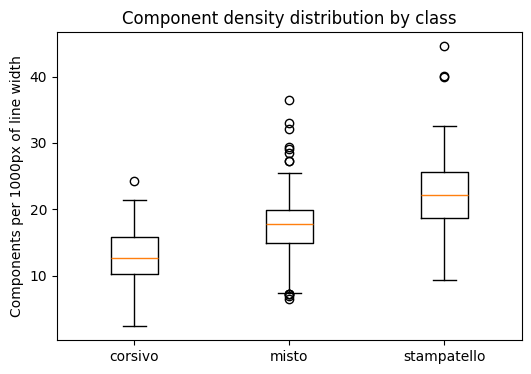

In [14]:
#Boxplot of feature 1 (component density) across all 147 samples per class

# Shows that cursive has fewer, larger blobs while printed has more, smaller ones
data = {
    "corsivo": densita_componenti("corsivo", n=147),
    "misto": densita_componenti("misto", n=147),
    "stampatello": densita_componenti("stampatello", n=147),
}

plt.figure(figsize=(6,4))
plt.boxplot(data.values(), tick_labels=data.keys())
plt.ylabel("Components per 1000px of line width")
plt.title("Component density distribution by class")
plt.show()

In [10]:
def conta_occhielli(img_bin, min_area=4):
  """
    Counts closed loops in a binary image using contour hierarchy.
    A loop is any background area fully enclosed inside an ink blob
    (like the inner part of 'a', 'o', 'e', 'b' ..).
    Works on _otsu.png files () morphological opening is not applied
    because it breaks the thin strokes that close letter loops).

    Parameters ->
        img_bin: binary image (ink=255, background=0), from _otsu.png file.
        min_area: minimum area in pixels to exclude noise holes.

    Returns ->
        occhielli: integer count of loops found in the image.
    """

  contours, hierarchy = cv2.findContours(
      img_bin,
      cv2.RETR_CCOMP, # returns contours at two levels: outer and holes
      cv2.CHAIN_APPROX_SIMPLE)
  occhielli = 0
  for i, h in enumerate(hierarchy[0]):
    parent = h[3]
    if parent != -1:   #contours with a parent are holes (loops)
      area = cv2.contourArea(contours[i])
      if area > min_area:
        occhielli += 1
  return occhielli

In [11]:
def draw_occhielli (img, img_bin, min_area=4):
  """
    Draws the contours of detected loops on a color image.
    Used to visually verify that detected holes correspond to
    real letter loops and not to noise.

    Parameters ->
        img_color: color image (BGR) to draw on.
        img_bin: binary image (ink=255, background=0), from _otsu.png file.
        min_area: minimum area to filter out noise holes.

    Returns ->
        debug_img: copy of the image with loop contours drawn in green.
    """
  debug_img = img.copy()

  contours, hierarchy = cv2.findContours(
      img_bin,
      cv2.RETR_CCOMP,
      cv2.CHAIN_APPROX_SIMPLE
  )
  for i, h in enumerate(hierarchy[0]):
    if h[3] != -1 and cv2.contourArea(contours[i]) > min_area:
      #draw contour i in green (0,255,0) with thickness 2
      cv2.drawContours(debug_img, contours, i, (0,255,0),2)
  return debug_img

In [12]:


def densita_occhielli(class_name, n=15, min_area=4):
    """
    Computes the density of closed loops per 1000px of line width.
    Cursive writing tends to have more loops than printed text
    (rounder and more connected letters).
    Works on _otsu.png files without morphological opening.

    Parameters:
        class_name: name of the class ('corsivo', 'misto', 'stampatello').
        n: number of samples to analyze.
        min_area: minimum area threshold to filter false positives.

    Returns:
        ratios: list of float values (loops per 1000px) for each sample.
    """
    paths = list((output_path / class_name).glob("*_otsu.png"))[:n]
    ratios = []
    for path in paths:
        otsu = cv2.imread(str(path), cv2.IMREAD_GRAYSCALE)
        contours, hierarchy = cv2.findContours(
            otsu,
            cv2.RETR_CCOMP,
            cv2.CHAIN_APPROX_SIMPLE
        )
        # Count only inner contours (holes), filtering out noise by area
        occhielli = sum(
            1 for i, h in enumerate(hierarchy[0])
            if h[3] != -1 and cv2.contourArea(contours[i]) > min_area
        )
        # Normalize by line width to compare lines of different lengths
        ys, xs = np.where(otsu > 0)
        line_width = xs.max() - xs.min() if len(xs) > 0 else 1
        ratios.append(occhielli / line_width * 1000)
    return ratios

# Feature 2 validation : loop density across all samples per class
for cls in ["corsivo", "misto", "stampatello"]:
  ratios = densita_occhielli(cls, n=147)
  print(f"{cls}: n={len(ratios)}, media={statistics.mean(ratios):.2f}, min={min(ratios):.2f}, max={max(ratios):.2f},dev_std={statistics.stdev(ratios):.2f}")

corsivo: n=147, media=8.47, min=0.57, max=18.85,dev_std=3.67
misto: n=147, media=8.35, min=1.10, max=17.48,dev_std=3.19
stampatello: n=147, media=7.51, min=1.71, max=16.21,dev_std=2.83


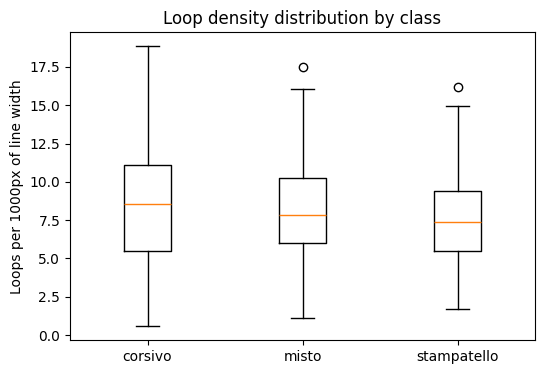

In [16]:
# Store loop density results for each class
data["occhielli_corsivo"] = densita_occhielli("corsivo", n=147)
data["occhielli_misto"] = densita_occhielli("misto", n=147)
data["occhielli_stampatello"] = densita_occhielli("stampatello", n=147)


# Boxplot of feature 2 (loop density) across all 147 samples per class
#separation between classes is weaker than feature 1
data_occhielli = {
    "corsivo": data["occhielli_corsivo"],
    "misto": data["occhielli_misto"],
    "stampatello": data["occhielli_stampatello"],
}

plt.figure(figsize=(6,4))
plt.boxplot(data_occhielli.values(), tick_labels=data_occhielli.keys())
plt.ylabel("Loops per 1000px of line width")
plt.title("Loop density distribution by class")
plt.show()

In [ ]:
def larghezza_media_blob(class_name, n=15):
  """
    Computes the average width of connected components (blobs),
    normalized by line width, per 1000px.
    In cursive, letters merge into wide blobs. In printed text,
    each letter is a separate, narrower blob.
    Works on _clean.png files.

    Parameters ->
        class_name: name of the class ('corsivo', 'misto', 'stampatello').
        n: number of samples to analyze.

    Returns ->
        ratios: list of float values for each sample.
    """
  paths = list((output_path/class_name).glob("*_clean.png"))[:n]
  ratios = []
  for path in paths:
    clean = cv2.imread(str(path), cv2.IMREAD_GRAYSCALE)
    stats,_ = get_components(clean, min_area=4)
    #if no ink id detected
    if len(stats)==0:
      continue
    ys,xs=np.where(clean>0)
    line_width = xs.max()-xs.min() if len(xs)>0 else 1
    #stats[:,2] is the width column of each blob's bounding box
    media_larghezza = np.mean(stats[:,2])/line_width*1000
    ratios.append(media_larghezza)
  return ratios

In [ ]:
def varianza_distanza_blob(class_name, n=15):
  """
    Computes the variance of horizontal distances between consecutive
    component centroids.
    Measures spacing regularity: printed text has more uniform spacing
    between isolated letters, while cursive varies more

    Works on _clean.png files

    Parameters ->
        class_name: name of the class ('corsivo', 'misto', 'stampatello').
        n: number of samples to analyze.

    Returns ->
        variances: list of float values (px squared) for each sample.
    """
  paths = list((output_path/class_name).glob("*_clean.png"))[:n]
  variances = []
  for path in paths:
    clean = cv2.imread(str(path), cv2.IMREAD_GRAYSCALE)
    stats, centroids = get_components(clean, min_area=4)

    # need at least 2 components to compute a distance
    if len(stats) < 2:
      continue

    # extract x coordinates of centroids and sort left to right
    xs_centroidi =np.sort(centroids[:,0])

    # compute distances between consecutive centroids
    distances = np.diff(xs_centroidi)

    #high variance would be irregular spacing -> cursive
    variances.append(np.var(distances))
  return variances

In [ ]:
# Feature 3 and 4 validation. Average blob width and distance variance per class
for cls in ["corsivo", "misto", "stampatello"]:
  r3 = larghezza_media_blob(cls, n=147)
  r4 = varianza_distanza_blob(cls, n=147)
  print(f"{cls}: mean width={statistics.mean(r3):.2f}, dev_std={statistics.stdev(r3):.2f}")
  print(f"{cls}: mean variance={statistics.mean(r4):.2f}, dev_std={statistics.stdev(r4):.2f}")

corsivo: mean width=41.29, dev_std=21.46
corsivo: mean variance=3591.67, dev_std=4528.84
misto: mean width=30.66, dev_std=26.47
misto: mean variance=1780.21, dev_std=1110.28
stampatello: mean width=22.88, dev_std=8.01
stampatello: mean variance=930.63, dev_std=510.42


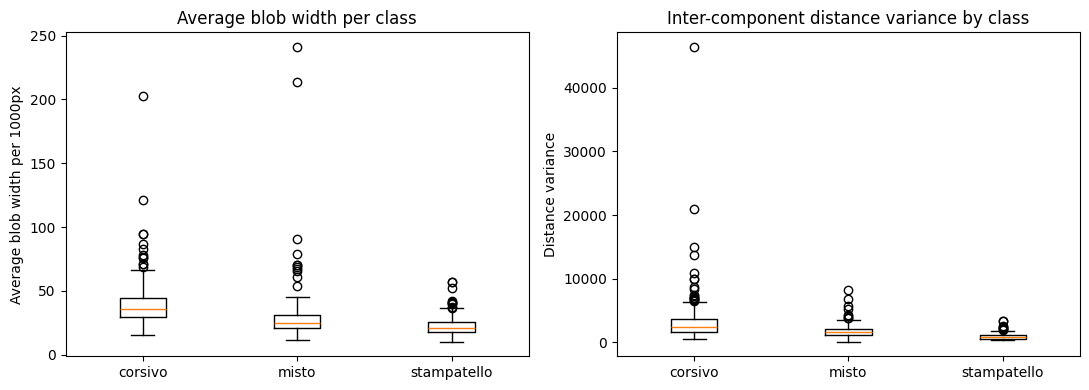

In [ ]:
#boxplots for features 3 and 4
fig, axes = plt.subplots(1,2, figsize=(11,4))

data_larghezza = { cls:larghezza_media_blob(cls, n=147) for cls in ["corsivo", "misto", "stampatello"]}
data_varianza = { cls:varianza_distanza_blob(cls, n=147) for cls in ["corsivo", "misto", "stampatello"]}

axes[0].boxplot(data_larghezza.values(), tick_labels=data_larghezza.keys())
axes[0].set_ylabel("Average blob width per 1000px")
axes[0].set_title("Average blob width per class")

axes[1].boxplot(data_varianza.values(), tick_labels=data_varianza.keys())
axes[1].set_ylabel("Distance variance")
axes[1].set_title("Inter-component distance variance by class")

plt.tight_layout()
plt.show()


In [ ]:

def estrai_hog(img_bin, pixels_per_cell=(16, 16), orientations=8):
    """
    Extracts a HOG (Histogram of Oriented Gradients) descriptor
    from a binary image.
    The image is resized to 256x64 pixels before computing HOG,
    to ensure a fixed-length output regardless of original image size.
    With default parameters, produces a 512-dimensional vector.

    Parameters:
        img_bin: binary image (ink=255, background=0), from _otsu.png file.
        pixels_per_cell: size of each cell in pixels.
        orientations: number of bins for the gradient orientation histogram.

    Returns:
        features: numpy array of 512 floats with the HOG descriptor.
    """
    # Resize to fixed dimensions so all HOG vectors have the same length
    img_resized = cv2.resize(img_bin, (256, 64))
    features = hog(
        img_resized,
        pixels_per_cell=pixels_per_cell,
        orientations=orientations,
        cells_per_block=(1, 1),
        visualize=False
    )
    return features

In [ ]:
#verify HOG vector shape is consistent across all classes
#expected shpe =(512,), values between 0 and 1
for cls in ["corsivo", "misto", "stampatello"]:
  sample_path = next((output_path/cls).glob("*_otsu.png"))
  otsu = cv2.imread(str(sample_path), cv2.IMREAD_GRAYSCALE)
  features = estrai_hog(otsu)
  print(f"{cls}: vettore HOG shape={features.shape}, min={features.min():.3f}, max={features.max():.3f}")

corsivo: vettore HOG shape=(512,), min=0.000, max=0.998
misto: vettore HOG shape=(512,), min=0.000, max=1.000
stampatello: vettore HOG shape=(512,), min=0.000, max=1.000


In [ ]:
def estrai_features_immagine(img_path,classe):
  """
    Extracts the full feature vector for a single image.
    Combines the 4 scalar features (component density, loop density,
    average blob width, distance variance) with the HOG vector (512 dims)
    into a single 516-dimensional array.

    Parameters ->
        img_path: path to the _otsu.png file of the image.
        classe: numeric class label (0=cursive, 1=mixed, 2=printed).

    Returns ->
        features_vector: numpy array of 516 floats, or None if the image
                         cannot be read.
        classe: numeric class label (unchanged).
    """
  # load both clean version for connectivity features and otsu for loop and HOG
  clean = cv2.imread(str(img_path).replace("_otsu.png", "_clean.png"), cv2.IMREAD_GRAYSCALE)
  otsu = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
  if clean is None or otsu is None:
    return None, None

  #components and line width used by f1, f2, f3 and f4
  stats, centroids = get_components(clean, min_area=4)
  ys, xs, = np.where(clean>0)
  line_width = xs.max()-xs.min() if len(xs) > 0 else 1

  # Feature 1: component density
  f1=len(stats) / line_width *1000

  # Feature 2: loop density
  contours, hierarchy = cv2.findContours(
      otsu,
      cv2.RETR_CCOMP,
      cv2.CHAIN_APPROX_SIMPLE)
  occhielli = sum(
      1 for i, h in enumerate(hierarchy[0]) if h[3] != -1 and cv2.contourArea(contours[i]) > 4
  )
  f2=occhielli/line_width*1000

  # Feature 3: average blob width
  f3=np.mean(stats[:,2])/line_width*1000 if len(stats)>0 else 0

  # Feature 4: variance of inter-component distances
  if len(centroids) >= 2:
   xs_c = np.sort(centroids[:,0])
   f4 = np.var(np.diff(xs_c))
  else:
   f4 = 0

  # Feature 5: HOG descriptor
  hog_features = estrai_hog(otsu)

  # Combine alla features into a single vector
  features_vector = np.concatenate([[f1,f2,f3, f4], hog_features])
  return features_vector, classe

def costruisci_dataset():
  """
    Builds the full dataset by iterating over all images of the three classes.
    For each image, calls estrai_features_immagine and collects the feature
    vectors into array X and the labels into array y.

    Returns ->
        X: numpy array of shape (441, 516) with the feature vectors.
        y: numpy array of shape (441,) with the labels (0, 1, 2).
    """
  X = []
  y = []

  # Map class names to numeric lables
  label_map = {"corsivo": 0, "misto": 1, "stampatello": 2}
  for cls in ["corsivo", "misto", "stampatello"]:
    paths = list((output_path/cls).glob("*_otsu.png"))
    print(f"{cls}: {len(paths)} immagini trovate")
    for path in paths:
      fv, label = estrai_features_immagine(path, label_map[cls])
      # skip images that coud not read
      if fv is not None:
        X.append(fv)
        y.append(label)
  X = np.array(X)
  y = np.array(y)
  print(f"\nDataset: {X.shape[0]} samples, {X.shape[1]} features per sample")
  return X,y

X, y = costruisci_dataset()

corsivo: 147 immagini trovate
misto: 147 immagini trovate
stampatello: 147 immagini trovate

Dataset: 441 samples, 516 features per sample


In [ ]:
# Normalize features to zero mean and unit variance
#Required before SVM and improves Random Forest stability

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
# verify dataset dimensions and label values

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Unique values:", np.unique(y))

X shape: (441, 516)
y shape: (441,)
Unique values: [0 1 2]


In [ ]:
# 5-fold stratified cross-validation preserves calss proportions in each fold
# shuffle=true randomizes sample order before splitting
# random_state=42 ensures reproducibility

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# metrics to evaluate
scoring = {
    "accuracy":make_scorer(accuracy_score),
    "f1_macro":make_scorer(f1_score, average="macro"),

}

# Compare SVM and Random forest on the same cross-validation splits
models = {
    "SVM": SVC(kernel="rbf", C=10, gamma="scale", random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
}

for name, model in models.items():
  results = cross_validate(
      model,
      X_scaled,
      y,
      cv=cv,
      scoring=scoring,

  )
  acc= results["test_accuracy"]
  f1=results["test_f1_macro"]
  print(f"\n{name}:")
  print(f"  accuracy: mena={acc.mean():.3f}, std={acc.std():.3f}")
  print(f"  f1_macro: mean={f1.mean():.3f}, std={f1.std():.3f}")


SVM:
  accuracy: mena=0.590, std=0.042
  f1_macro: mean=0.588, std=0.043

Random Forest:
  accuracy: mena=0.644, std=0.053
  f1_macro: mean=0.635, std=0.054


              precision    recall  f1-score   support

     corsivo       0.70      0.79      0.74        29
       misto       0.68      0.50      0.58        30
 stampatello       0.68      0.77      0.72        30

    accuracy                           0.69        89
   macro avg       0.69      0.69      0.68        89
weighted avg       0.68      0.69      0.68        89



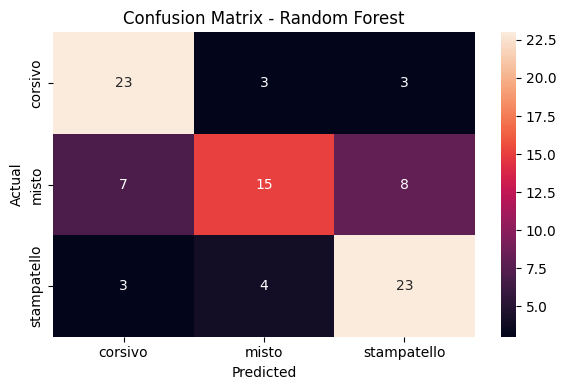

In [ ]:

# Final evaluation on test set (20% of data, stratified)
# Using Random Forest
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, stratify=y, random_state=42
)

# Train on 80% and predict on the remaining 20%
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

# Per-class metrics : Precision, recall, F1
print(classification_report(y_test, y_pred, target_names=["corsivo", "misto", "stampatello"]))

# Confusion matrix

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=["corsivo", "misto", "stampatello"],
            yticklabels=["corsivo", "misto", "stampatello"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Random Forest")
plt.tight_layout()
plt.show()

In [ ]:
def postprocessing(model, X_scaled, threshold=0.6):
    """
    Applies confidence thresholding to classification results.
    Predictions where the maximum class probability is below
    the threshold are rejected as uncertain, rather than forced
    into a potentially wrong class.

    Parameters:
        model: trained classifier with predict_proba support.
        X_scaled: scaled feature array.
        threshold: minimum confidence threshold (default 0.6).

    Returns:
        predictions: list of predicted labels or 'uncertain'.
        confidences: list of maximum probabilities for each sample.
    """
    # Get class probabilities for each sample (shape: n_samples x n_classes)
    probabilities = model.predict_proba(X_scaled)
    predictions = []
    confidences = []

    for probs in probabilities:
        max_prob = np.max(probs)
        confidences.append(round(max_prob, 3))
        if max_prob >= threshold:
            # Assign the class with the highest probability
            predictions.append(model.classes_[np.argmax(probs)])
        else:
            # Reject low-confidence predictions
            predictions.append("uncertain")
    return predictions, confidences

# Post-processing: test different confidence thresholds
for threshold in [0.35, 0.40, 0.45, 0.5]:
    preds, confs = postprocessing(rf, X_test, threshold)
    n_uncertain = preds.count("uncertain")
    n_classified = len(preds) - n_uncertain
    print(f"Threshold {threshold}: {n_classified} classified, {n_uncertain} uncertain")

Threshold 0.35: 89 classified, 0 uncertain
Threshold 0.4: 74 classified, 15 uncertain
Threshold 0.45: 52 classified, 37 uncertain
Threshold 0.5: 33 classified, 56 uncertain


GPU disponibile: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Dataset:(441, 224, 224, 3), etichette:(441,)
Train:352, Val:89


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │         3,843 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,261,827 (8.63 MB)

 Trainable params: 3,843 (15.01 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

Epoch 1/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 18s 388ms/step - accuracy: 0.3551 - loss: 1.2161 - val_accuracy: 0.4045 - val_loss: 1.1255
Epoch 2/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - accuracy: 0.4545 - loss: 1.0762 - val_accuracy: 0.4607 - val_loss: 1.0704
Epoch 3/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.4972 - loss: 1.0051 - val_accuracy: 0.4382 - val_loss: 1.0517
Epoch 4/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.4943 - loss: 0.9936 - val_accuracy: 0.4045 - val_loss: 1.0653
Epoch 5/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.5398 - loss: 0.9253 - val_accuracy: 0.4494 - val_loss: 1.0505
Epoch 6/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.5710 - loss: 0.9144 - val_accuracy: 0.4157 - val_loss: 1.0705
Epoch 7/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.5966 - loss: 0.8513 - val_accuracy: 0.4270 - val_loss: 1.0628
Epoch 8/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.6108 - loss: 0.8390 - val_accuracy: 0.4607 -

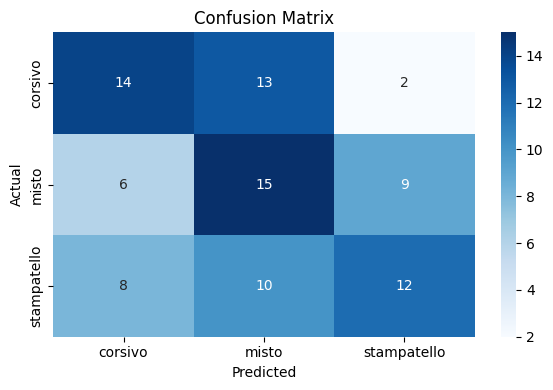

In [ ]:
# Check GPU availability

print("GPU disponibile:", tf.config.list_physical_devices("GPU"))

def carica_dataset(output_path, img_size=(224,224)):
  """
    Loads raw images for the deep learning model (MobileNetV2).
    Unlike costruisci_dataset, does not extract handcrafted features
    but returns pixels resized to 224x224 in RGB format,
    normalized to the range [0, 1].

    Parameters ->
        output_path: path to the dataset_graph_processed folder.
        img_size: target size for resizing.

    Returns ->
        X: numpy array of shape (441, 224, 224, 3) with normalized pixels.
        y: numpy array of shape (441,) with the labels (0, 1, 2).
    """
  X = []
  y = []
  label_map = {}
  label_map["corsivo"] = 0
  label_map["misto"] = 1
  label_map["stampatello"] = 2
  for cls in ["corsivo", "misto", "stampatello"]:
    paths = list((output_path/cls).glob("*_otsu.png"))
    for path in paths:
      img = cv2.imread(str(path), cv2.IMREAD_GRAYSCALE)
      img = cv2.resize(img, img_size)

      # MobileNetV2 expects 3-channels RGB input
      img_rgb = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
      X.append(img_rgb)
      y.append(label_map[cls])

  # Normalize pixel values from [0, 255] to [0,1]
  X = np.array(X, dtype="float32")/255.0
  y = np.array(y)

  return X,y

X_img, y_img = carica_dataset(output_path)
print(f"Dataset:{X_img.shape}, etichette:{y_img.shape}")


# stratified split: 80% train, 20% validation

X_train, X_val, y_train, y_val = train_test_split(
    X_img, y_img, test_size=0.2, stratify=y_img, random_state=42
)
print(f"Train:{len(X_train)}, Val:{len(X_val)}")


# Load MobileNetV2 pre-trained on ImageNet, without its original classification head
base_model = keras.applications.MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(224,224,3)
)

#Freeze all pre-trained weights — only the new head will be trained
base_model.trainable = False

# Add a small classification head for our 3 classes
model=keras.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.2),
    layers.Dense(3, activation="softmax")
])
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()


# Train only the classification head for 10 epochs
history=model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=10,
    batch_size=16
)



# Evaluate on validation set: argmax converts softmax probabilities to class labels
y_pred = np.argmax(model.predict(X_val), axis=1)

print(classification_report(y_val, y_pred, target_names=["corsivo", "misto", "stampatello"]))
cm = confusion_matrix(y_val, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=["corsivo", "misto", "stampatello"],
            yticklabels=["corsivo", "misto", "stampatello"], cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()
